In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append('..')
from SRC import sp_limpieza_bank as slb 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('../Data/data_limpios_bank.csv')
df.head()

,age,job_grouped,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_,year
0,NaN,manual,married,basic 4y,0.0000,0.0000,0.0000,telephone,261,1,999,0,nonexistent,1.1000,94.0000,-36.4000,4.9000,5191,no,2019-08-02,41.4950,-71.2330,089b39d8-e4d0-461b-87d4-814d71e0e079,2019
1,57.0000,technical,married,high school,NaN,0.0000,0.0000,telephone,149,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2016-09-14,34.6010,-83.9230,e9d37224-cb6f-4942-98d7-46672963d097,2016
2,37.0000,technical,married,high school,0.0000,1.0000,0.0000,telephone,226,1,999,0,nonexistent,1.1000,94.0000,-36.4000,4.9000,5191,no,2019-02-15,34.9390,-94.8470,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019
3,40.0000,administrative,married,basic 6y,0.0000,0.0000,0.0000,telephone,151,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2015-11-29,49.0410,-70.3080,9991fafb-4447-451a-8be2-b0df6098d13e,2015
4,56.0000,technical,married,high school,0.0000,0.0000,1.0000,telephone,307,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2017-01-29,38.0330,-104.4630,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017


In [4]:
df['age'] = df['age'].astype('Int64')

In [5]:
columnas_num = df.select_dtypes(include=np.number).columns.tolist()
print(columnas_num)
lista_eliminar = ['default', 'housing', 'loan', 'latitude', 'longitude', 'year', 'nr_employed', 'pdays']
for col in lista_eliminar:
    columnas_num.remove(col)
columnas_num

['age', 'default', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'latitude', 'longitude', 'year']


['age',
 'duration',
 'campaign',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m']

In [6]:
df[columnas_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37880.0000,39.9771,10.4380,17.0000,32.0000,38.0000,47.0000,98.0000
duration,43000.0000,257.7393,258.6660,0.0000,102.0000,179.0000,319.0000,4918.0000
campaign,43000.0000,2.5672,2.7723,1.0000,1.0000,2.0000,3.0000,56.0000
previous,43000.0000,0.1740,0.4974,0.0000,0.0000,0.0000,0.0000,7.0000
emp_var_rate,43000.0000,0.0771,1.5739,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons_price_idx,42529.0000,93.5731,0.5844,92.2000,93.1000,93.7000,94.0000,94.8000
cons_conf_idx,43000.0000,-40.5090,4.6372,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000
euribor3m,33744.0000,3.6388,1.7555,0.6000,1.3000,4.9000,5.0000,5.0000


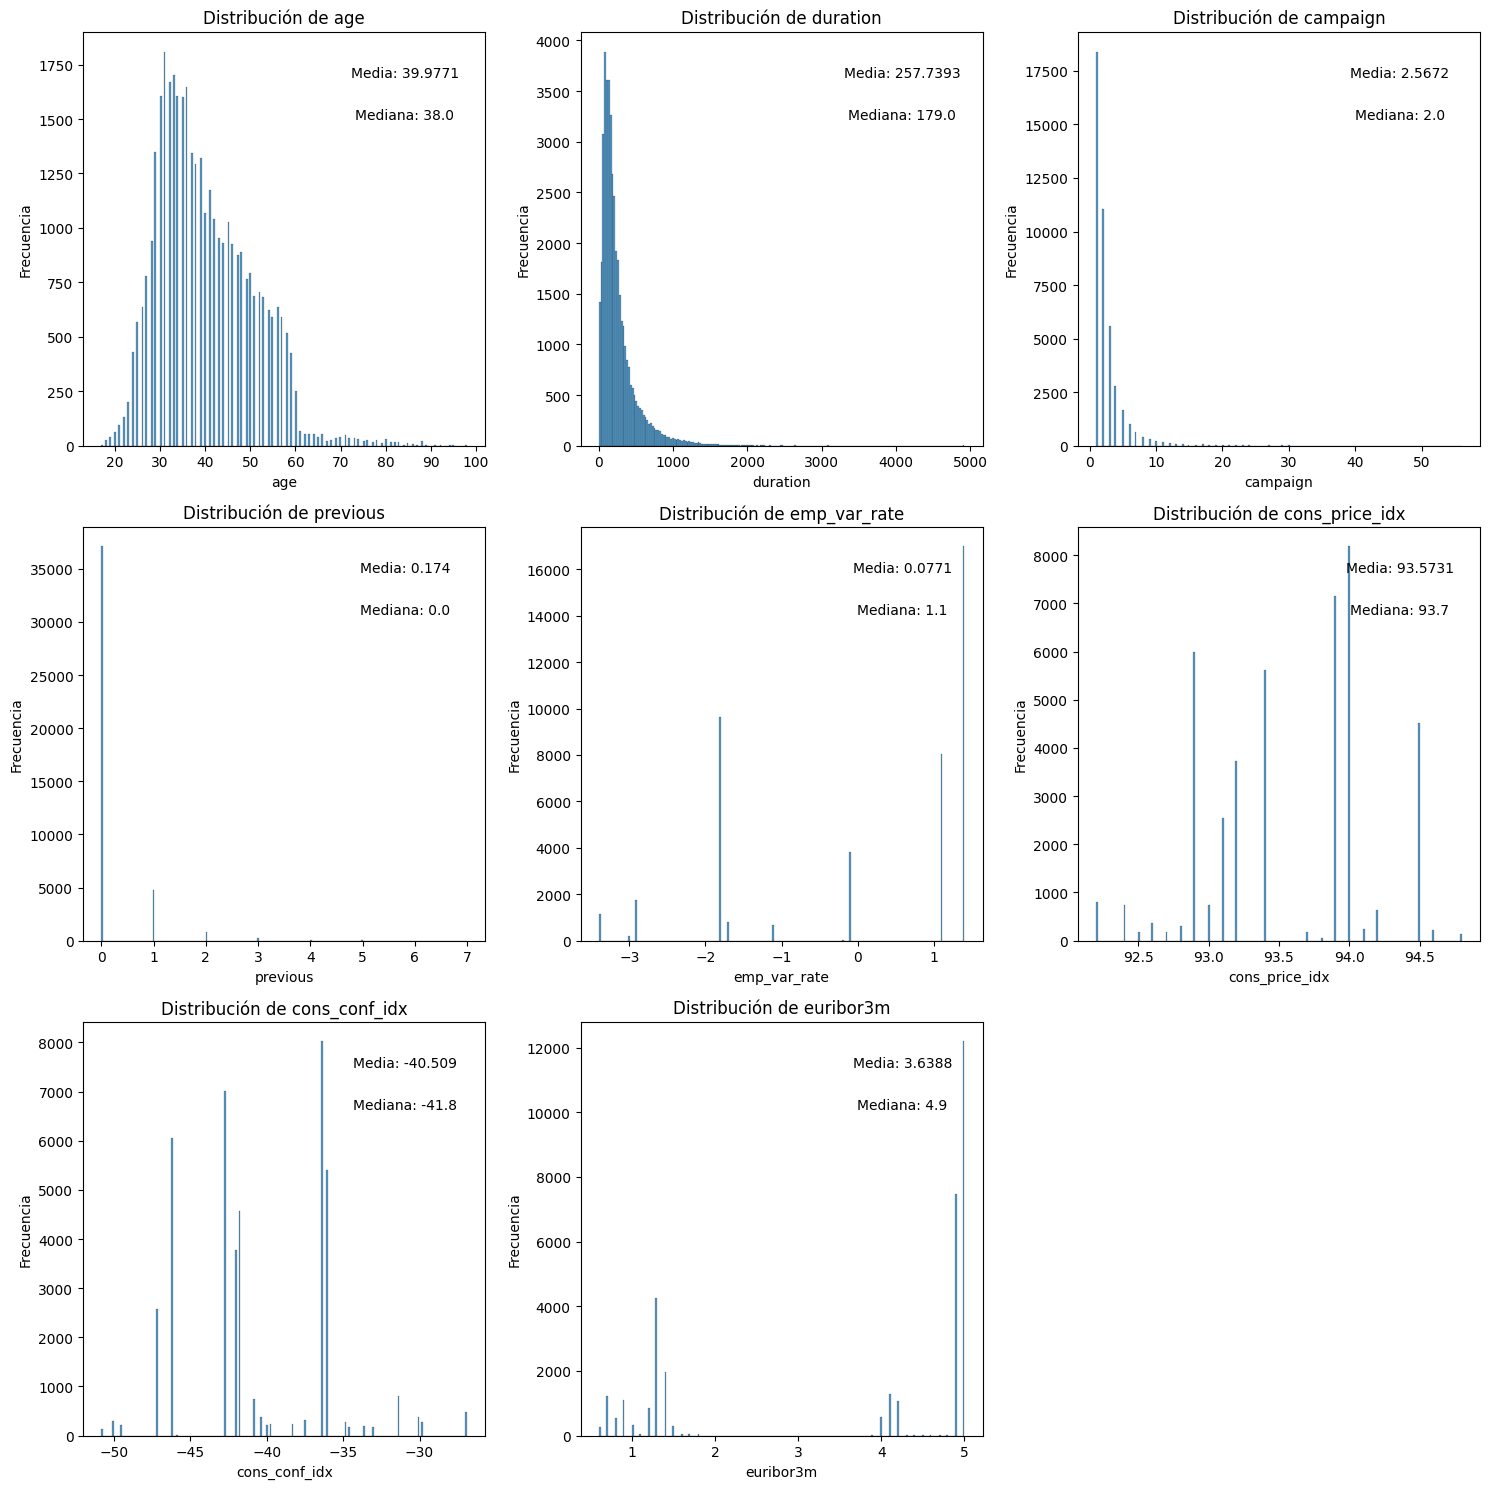

In [13]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//3

fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows*5))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.histplot(data=df, x=col, ax = axes[i], bins=200)
    axes[i].text(0.8, 0.9, f'Media: {round(df[col].mean(),4)}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].text(0.8, 0.8, f'Mediana: {df[col].median()}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

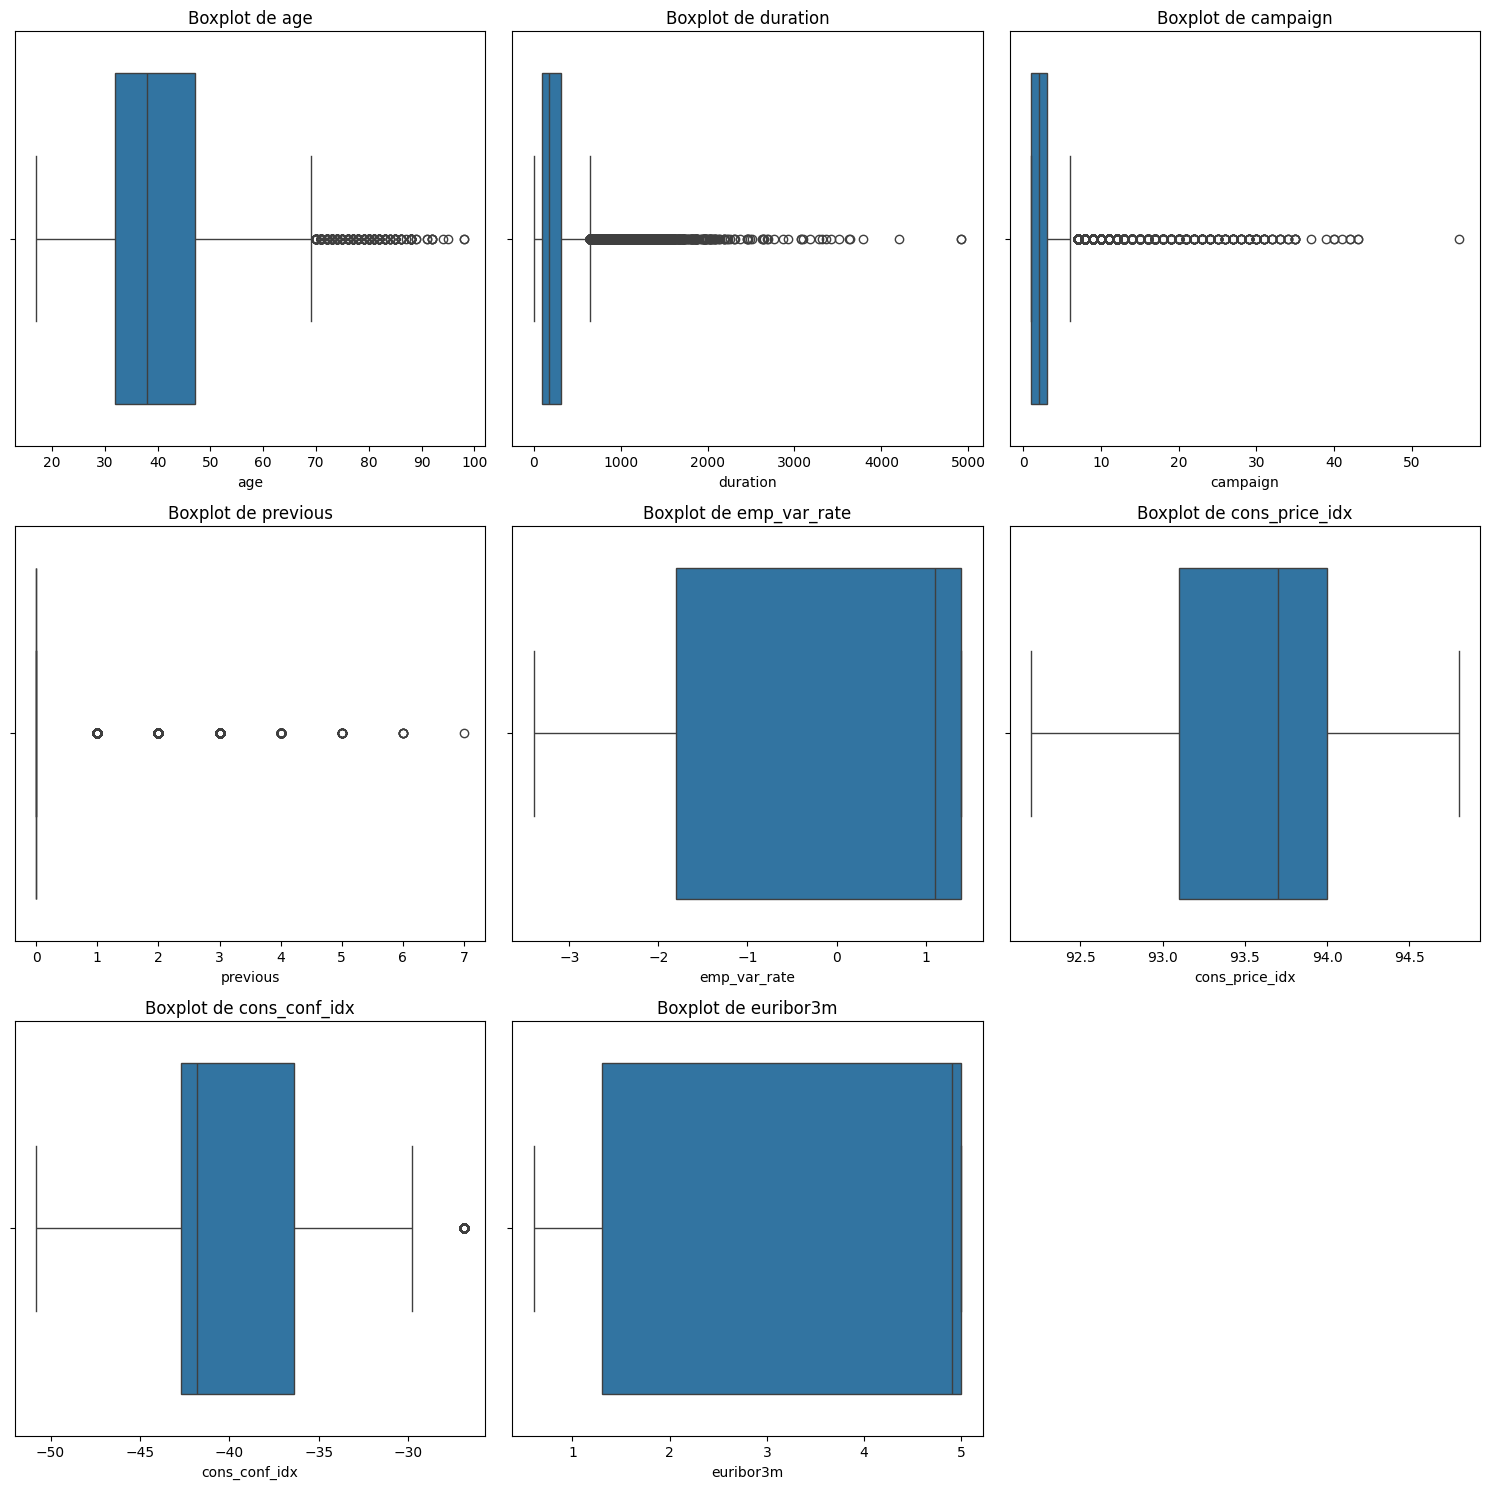

In [11]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//3

fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows*5))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.boxplot(data=df, x=col, ax = axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

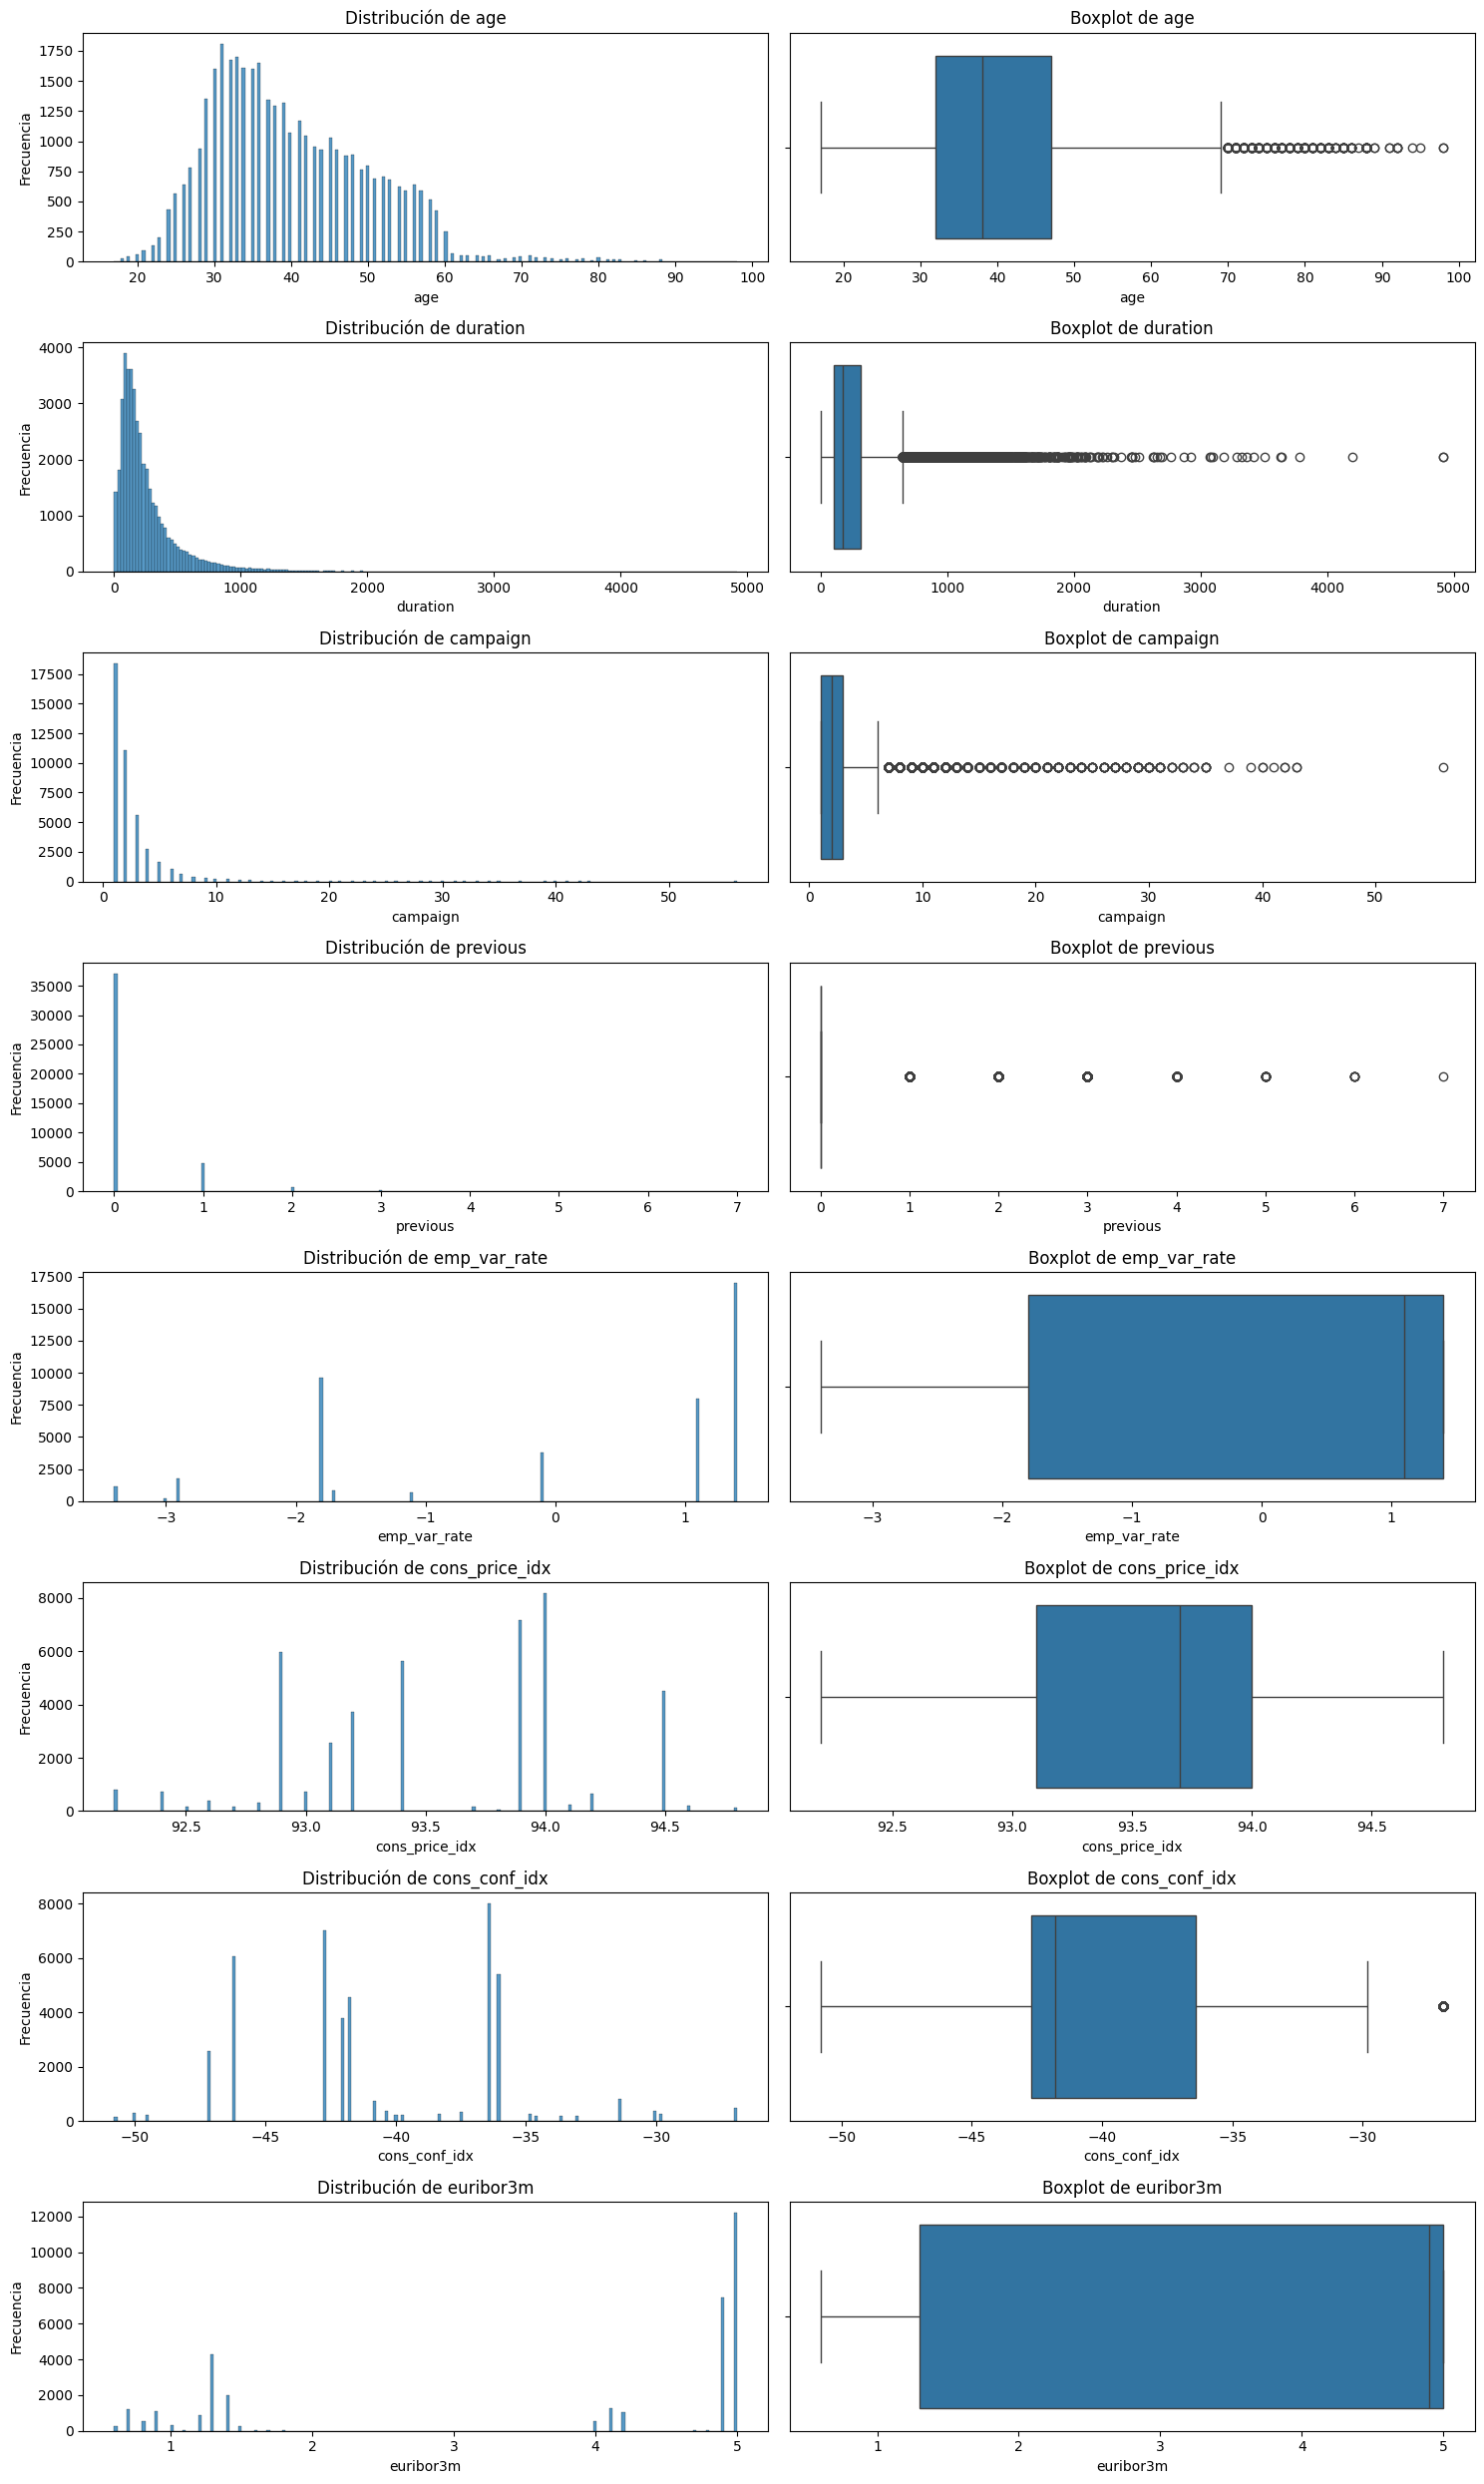

In [14]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//2

fig, axes = plt.subplots(num_graph, 2, figsize=(15, num_rows*5))

for i, col in enumerate(columnas_num):
    sns.histplot(data=df, x=col, ax = axes[i, 0], bins=200)
    axes[i, 0].set_title(f'Distribución de {col}')
    axes[i, 0].set_ylabel('Frecuencia')
    
    sns.boxplot(data=df, x=col, ax = axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()